# Manage results

This notebook will interpret the results from different maintenance rewards


In [40]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
# Update this path to your simulation results directory
# Look in multiple locations for hourly CSV files
#results_dir_old = Path('../../simulation_results/third_test_of_maintenance_rewards/CSV')
results_dir_root = Path('../../simulation_results')  # For TD_test_instance files

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [41]:
# Debug: Check if the paths exist and list files
import os

print(f"Current working directory: {os.getcwd()}")
print(f"\n--- Checking old results directory ---")
print(f"Path: {results_dir_old}")
print(f"Path exists: {results_dir_old.exists()}")
print(f"Is directory: {results_dir_old.is_dir()}")

"""if results_dir_old.exists():
    print(f"\nContents of {results_dir_old}:")
    hourly_files_old = list(results_dir_old.glob('*_hourly_seed_*.csv'))
    print(f"Found {len(hourly_files_old)} hourly CSV files")
    for f in hourly_files_old[:5]:
        print(f"  {f.name}")"""

print(f"\n--- Checking root results directory (TD_test_instance) ---")
print(f"Path: {results_dir_root}")
print(f"Path exists: {results_dir_root.exists()}")
print(f"Is directory: {results_dir_root.is_dir()}")

if results_dir_root.exists():
    hourly_files_root = list(results_dir_root.glob('*TD_test_instance*_hourly_seed_*.csv'))
    print(f"Found {len(hourly_files_root)} TD_test_instance hourly CSV files")
    for f in hourly_files_root[:5]:
        print(f"  {f.name}")

Current working directory: c:\Users\Minamsj\FOMOsim\policies\sjovik_sund\Scripts\Maintenance_reward_analysis

--- Checking old results directory ---
Path: ..\..\simulation_results\third_test_of_maintenance_rewards\CSV
Path exists: True
Is directory: True

--- Checking root results directory (TD_test_instance) ---
Path: ..\..\simulation_results
Path exists: True
Is directory: True
Found 3 TD_test_instance hourly CSV files
  sjovik_sund_alphas_run_TD_test_instance_0.001_results_hourly_seed_1.csv
  sjovik_sund_alphas_run_TD_test_instance_0.002_results_hourly_seed_1.csv
  sjovik_sund_alphas_run_TD_test_instance_0.003_results_hourly_seed_1.csv


In [42]:
def extract_alpha_from_filename(filename):
    """
    Extracts the alpha value from hourly CSV filenames like:
    - sjovik_sund_alphas_run2_0.001_results_hourly_seed_1.csv
    - sjovik_sund_alpha_0.01_results_hourly_seed_1.csv
    - sjovik_sund_alphas_run_TD_test_instance_0.001_results_hourly_seed_1.csv
    """
    # Regex to find alpha value in filename - handles both patterns
    # Pattern 1: alphas_run..._0.001 (non-greedy match to skip over intermediate text)
    # This handles both alphas_run2_0.001 and alphas_run_TD_test_instance_0.001
    match = re.search(r'alphas_run.*?_([\d\.]+)', filename)
    if match:
        return float(match.group(1))
    # Pattern 2: alpha_0.01 (fallback for other patterns)
    match = re.search(r'alpha[a-z0-9_]*_([\d\.]+)', filename)
    if match:
        return float(match.group(1))
    return None

def wrap_hour_to_display(hour):
    """
    Maps hours 7-30 to display hours 7-6 (07:00 to 06:00 next day).
    Hours 7-24 stay as is, hours 25-30 map to 1-6.
    Returns a tuple: (display_hour, sort_key) where sort_key ensures correct ordering
    """
    if 7 <= hour <= 24:
        return hour, hour  # Hours 7-24: display as 7-24, sort by original hour
    elif 25 <= hour <= 30:
        return hour - 24, hour  # Hours 25-30: display as 1-6, sort by original hour
    else:
        # Hours outside 7-30 range: map to None (will be filtered)
        return None, hour

# Find all hourly CSV files in both locations
hourly_files = []
#if results_dir_old.exists():
    #hourly_files.extend(list(results_dir_old.glob('*_hourly_seed_*.csv')))
if results_dir_root.exists():
    hourly_files.extend(list(results_dir_root.glob('*TD_test_instance*_hourly_seed_*.csv')))

print(f"Found {len(hourly_files)} hourly CSV files")
print(f"Files found:")
for f in hourly_files:
    print(f"  {f.name}")

# Load all hourly data
all_hourly_data = []
for file_path in hourly_files:
    alpha = extract_alpha_from_filename(file_path.name)
    if alpha is None:
        print(f"Warning: Could not extract alpha from {file_path.name}")
        continue
    
    try:
        df = pd.read_csv(file_path)
        df['alpha'] = alpha
        
        # Filter to keep only hours 7-30 (07:00 to 06:00 next day)
        df = df[(df['Hour'] >= 7) & (df['Hour'] <= 30)].copy()
        
        if len(df) > 0:
            # Map hours to display format: 7-24 stay, 25-30 become 1-6
            # Also create a sort key to maintain chronological order
            hour_mapping = df['Hour'].apply(wrap_hour_to_display)
            df['Display_Hour'] = hour_mapping.apply(lambda x: x[0])
            df['Sort_Key'] = hour_mapping.apply(lambda x: x[1])
            
            # Remove any rows that couldn't be mapped (outside 7-30 range)
            df = df[df['Display_Hour'].notna()].copy()
            
            # Aggregate data by display hour (in case multiple hours map to same display hour)
            # Group by Display_Hour and sum the violation counts
            violation_cols = ['Starvations', 'Long Congestions', 'Short Congestions', 
                            'Maintenance Violations', 'Maintenance Starvations']
            available_violation_cols = [col for col in violation_cols if col in df.columns]
            
            # Group by Display_Hour and sum violation columns, keep other columns from first row
            agg_dict = {col: 'sum' for col in available_violation_cols}
            agg_dict.update({col: 'first' for col in df.columns if col not in available_violation_cols and col not in ['Hour', 'Display_Hour', 'Sort_Key']})
            agg_dict['Sort_Key'] = 'min'  # Keep minimum sort key for ordering
            
            df = df.groupby('Display_Hour', as_index=False).agg(agg_dict)
            df = df.sort_values('Sort_Key')
            
            # Rename Display_Hour back to Hour for consistency
            df['Hour'] = df['Display_Hour']
            df = df.drop(['Display_Hour', 'Sort_Key'], axis=1)
        
        all_hourly_data.append(df)
        print(f"Loaded {file_path.name}: {len(df)} hours, alpha={alpha}")
    except Exception as e:
        print(f"Error loading {file_path.name}: {e}")

# Combine all data
if all_hourly_data:
    combined_df = pd.concat(all_hourly_data, ignore_index=True)
    print(f"\nTotal data points: {len(combined_df)}")
    print(f"Unique alpha values: {sorted(combined_df['alpha'].unique())}")
    print(f"Hour range: {combined_df['Hour'].min()} - {combined_df['Hour'].max()}")
    print(f"\nColumns: {list(combined_df.columns)}")
    print(f"\nFirst few rows:")
    print(combined_df.head())
    
    # Diagnostic: Check relationship between alpha and maintenance/violations
    print("\n" + "="*80)
    print("DIAGNOSTIC: Alpha vs Maintenance Time and Violations")
    print("="*80)
    
    # Aggregate by alpha (sum across all hours)
    alpha_summary = combined_df.groupby('alpha').agg({
        'Maintenance Time (minutes)': 'sum',
        'Maintenance Violations': 'sum',
        'Maintenance Starvations': 'sum',
        'Starvations': 'sum',
        'Bike Pickups': 'sum',
        'Bike Deliveries': 'sum'
    }).reset_index()
    
    alpha_summary = alpha_summary.sort_values('alpha')
    print("\nAggregated by Alpha (sum across all hours):")
    print(alpha_summary.to_string(index=False))
    
    print("\n" + "-"*80)
    print("Expected behavior: As alpha increases, maintenance time should increase,")
    print("and maintenance violations/starvations should DECREASE (not increase).")
    print("-"*80)
    
    # Check if maintenance time is increasing
    maint_times = alpha_summary['Maintenance Time (minutes)'].values
    if len(maint_times) > 1:
        maint_increasing = all(maint_times[i] <= maint_times[i+1] for i in range(len(maint_times)-1))
        print(f"\nMaintenance time increasing with alpha: {maint_increasing}")
        if not maint_increasing:
            print("⚠️  WARNING: Maintenance time is NOT increasing with alpha!")
    
    # Check if violations are decreasing
    maint_violations = alpha_summary['Maintenance Violations'].values
    maint_starvations = alpha_summary['Maintenance Starvations'].values
    if len(maint_violations) > 1:
        violations_decreasing = all(maint_violations[i] >= maint_violations[i+1] for i in range(len(maint_violations)-1))
        starvations_decreasing = all(maint_starvations[i] >= maint_starvations[i+1] for i in range(len(maint_starvations)-1))
        print(f"Maintenance violations decreasing with alpha: {violations_decreasing}")
        print(f"Maintenance starvations decreasing with alpha: {starvations_decreasing}")
        if not violations_decreasing or not starvations_decreasing:
            print("⚠️  WARNING: Maintenance violations/starvations are NOT decreasing with alpha!")
            print("   This suggests a bug in the objective function or constraint logic.")
    
else:
    print("No hourly data found!")


Found 3 hourly CSV files
Files found:
  sjovik_sund_alphas_run_TD_test_instance_0.001_results_hourly_seed_1.csv
  sjovik_sund_alphas_run_TD_test_instance_0.002_results_hourly_seed_1.csv
  sjovik_sund_alphas_run_TD_test_instance_0.003_results_hourly_seed_1.csv
Loaded sjovik_sund_alphas_run_TD_test_instance_0.001_results_hourly_seed_1.csv: 24 hours, alpha=0.001
Loaded sjovik_sund_alphas_run_TD_test_instance_0.002_results_hourly_seed_1.csv: 24 hours, alpha=0.002
Loaded sjovik_sund_alphas_run_TD_test_instance_0.003_results_hourly_seed_1.csv: 24 hours, alpha=0.003

Total data points: 72
Unique alpha values: [np.float64(0.001), np.float64(0.002), np.float64(0.003)]
Hour range: 1 - 24

Columns: ['Starvations', 'Long Congestions', 'Short Congestions', 'Maintenance Violations', 'Maintenance Starvations', 'Seed', 'Time (minutes)', 'Bike Pickups', 'Bike Deliveries', 'Maintenance Time (minutes)', 'alpha', 'Hour']

First few rows:
   Starvations  Long Congestions  Short Congestions  Maintenance Vio

In [43]:
# Define violation types to plot
violation_types = [
    'Starvations',
    'Long Congestions',
    'Short Congestions',
    'Maintenance Violations',
    'Maintenance Starvations'
]

# Verify all columns exist
available_columns = set(combined_df.columns)
missing = [v for v in violation_types if v not in available_columns]
if missing:
    print(f"Warning: Missing columns: {missing}")
    violation_types = [v for v in violation_types if v in available_columns]

print(f"Plotting {len(violation_types)} violation types: {violation_types}")


Plotting 5 violation types: ['Starvations', 'Long Congestions', 'Short Congestions', 'Maintenance Violations', 'Maintenance Starvations']


Creating plots for 3 alpha values: [np.float64(0.001), np.float64(0.002), np.float64(0.003)]
Saved: ..\..\simulation_results\hourly_violation_plots\hourly_violations_alpha_0.001.png
Saved: ..\..\simulation_results\hourly_violation_plots\hourly_violations_alpha_0.002.png
Saved: ..\..\simulation_results\hourly_violation_plots\hourly_violations_alpha_0.003.png


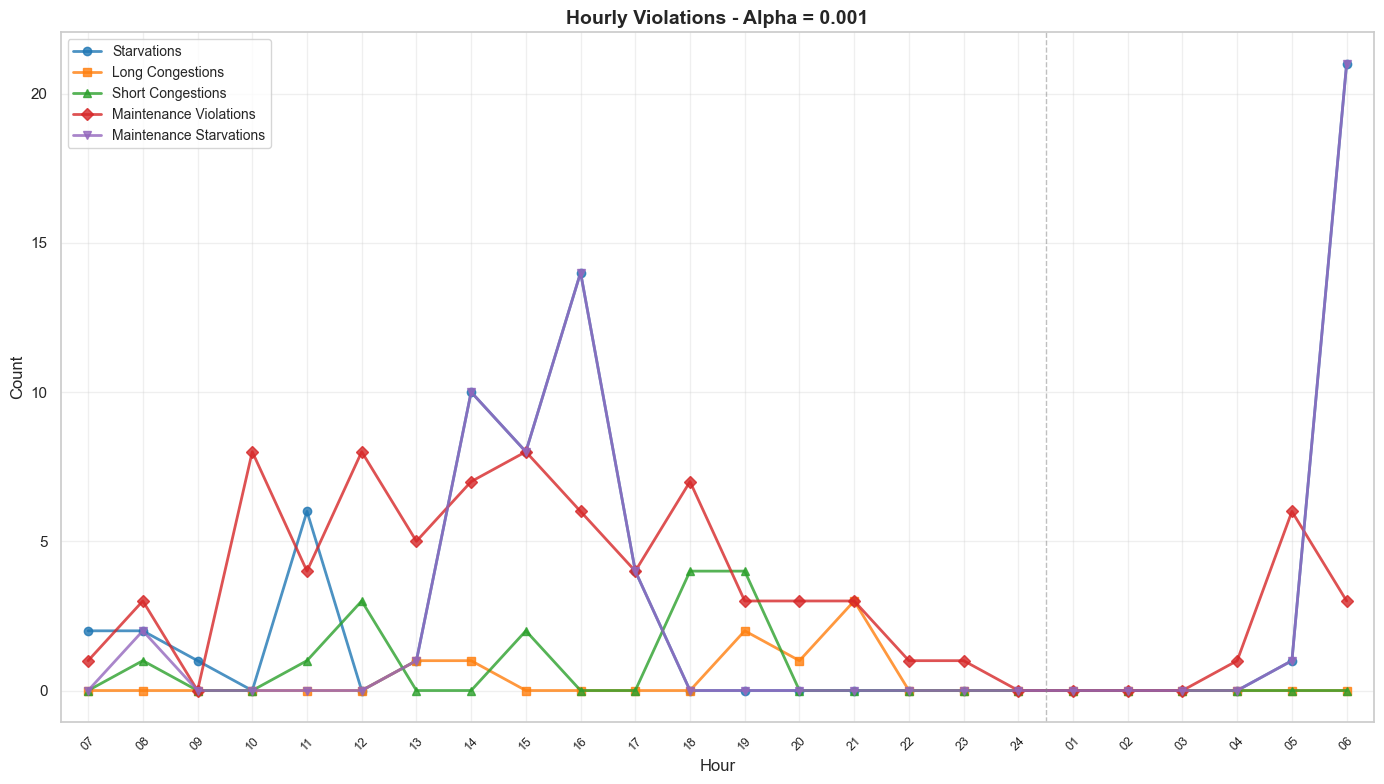

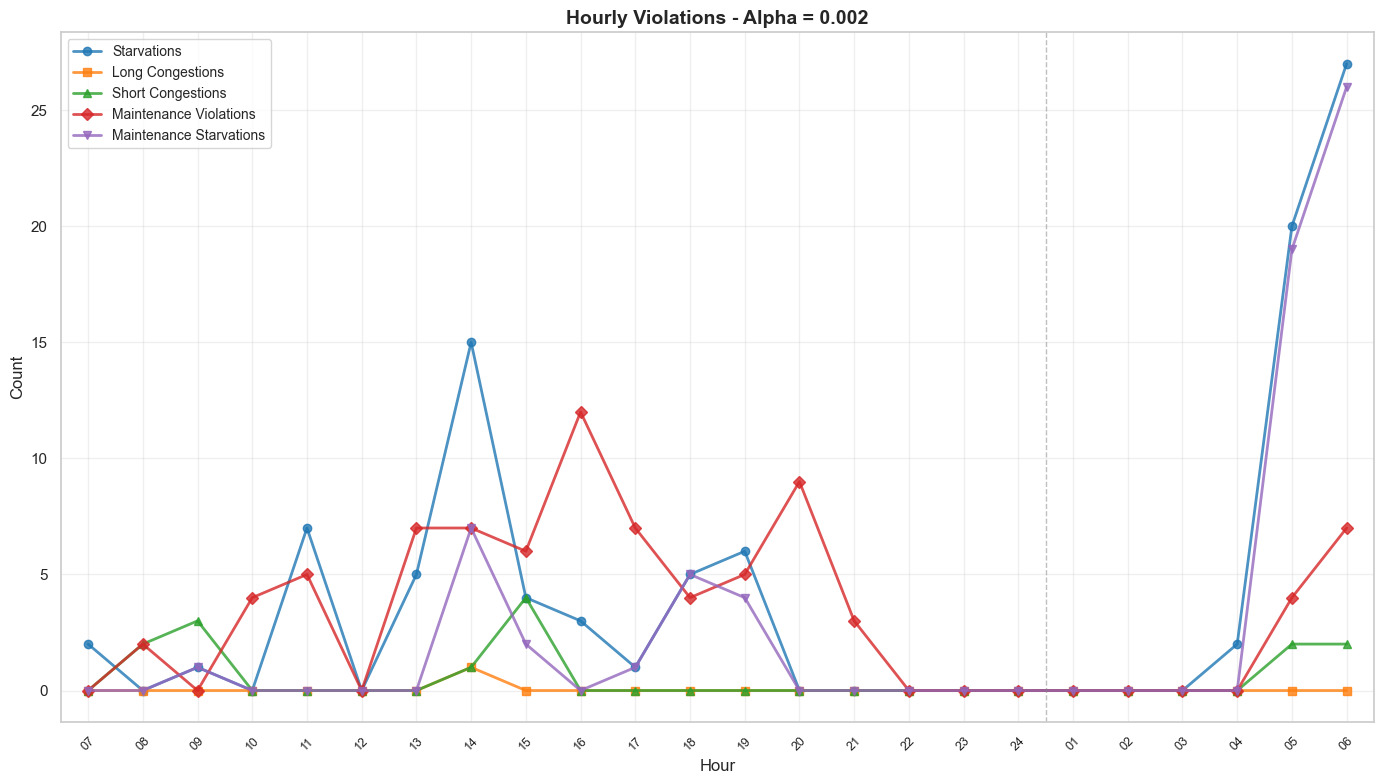

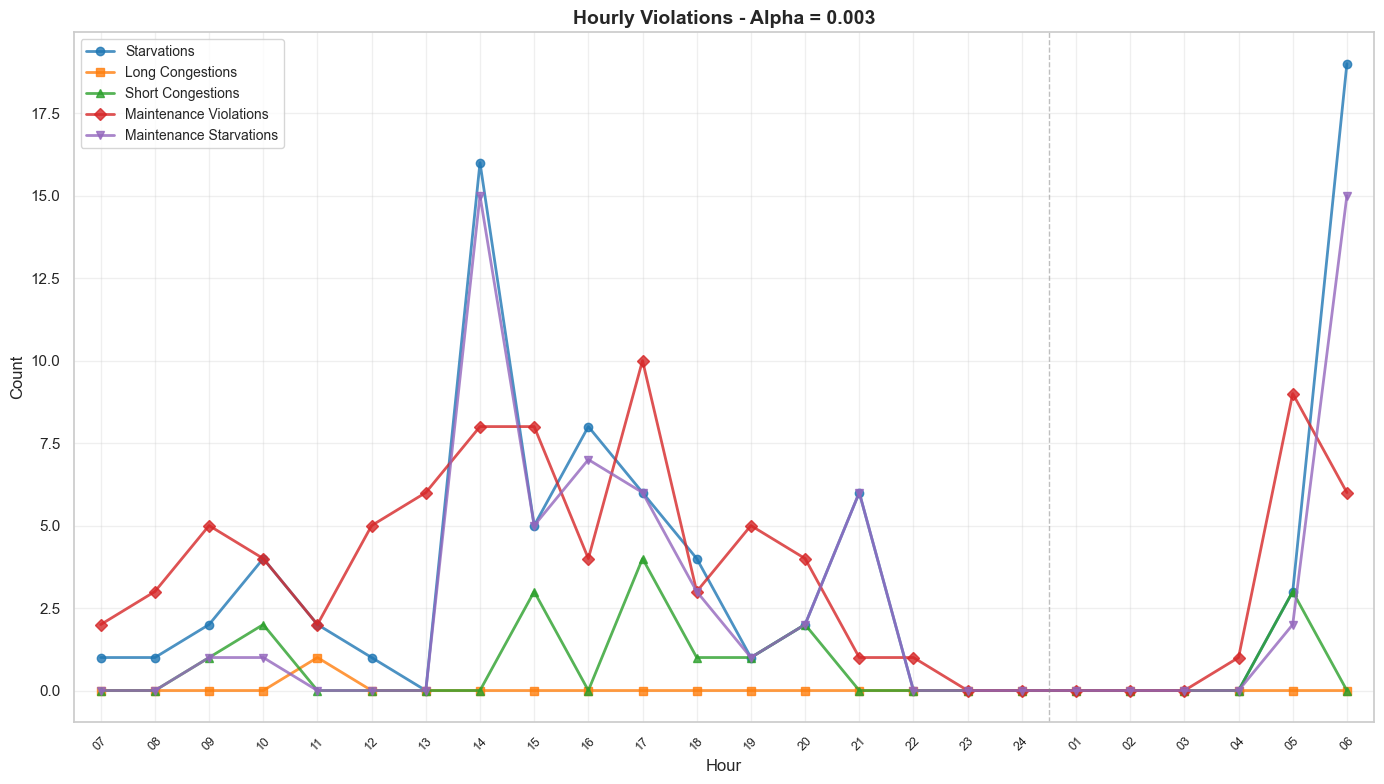

In [44]:
# Get unique alpha values and sort them
unique_alphas = sorted(combined_df['alpha'].unique())
print(f"Creating plots for {len(unique_alphas)} alpha values: {unique_alphas}")

# Create one plot per alpha value
for alpha in unique_alphas:
    # Filter data for this alpha
    alpha_data = combined_df[combined_df['alpha'] == alpha].copy()
    
    # Sort by hour
    alpha_data = alpha_data.sort_values('Hour')
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot each violation type as a separate line
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
    markers = ['o', 's', '^', 'D', 'v']
    
    # Create hour sequence for plotting: 7, 8, ..., 24, 1, 2, ..., 6
    hour_sequence = list(range(7, 25)) + list(range(1, 7))
    hour_mapping = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    
    # Create a sorted dataframe with hours in display order
    alpha_data_sorted = alpha_data.copy()
    alpha_data_sorted['Plot_Order'] = alpha_data_sorted['Hour'].map(hour_mapping)
    alpha_data_sorted = alpha_data_sorted.sort_values('Plot_Order')
    
    for i, violation_type in enumerate(violation_types):
        if violation_type in alpha_data_sorted.columns:
            ax.plot(
                alpha_data_sorted['Plot_Order'],
                alpha_data_sorted[violation_type],
                marker=markers[i % len(markers)],
                color=colors[i % len(colors)],
                label=violation_type,
                linewidth=2,
                markersize=6,
                alpha=0.8
            )
    
    # Customize plot
    ax.set_xlabel('Hour', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title(f'Hourly Violations - Alpha = {alpha:.3f}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to show hours 7-24, then 1-6 (07:00 to 06:00)
    if len(alpha_data) > 0:
        # Create hour sequence: 7, 8, ..., 24, 1, 2, ..., 6
        hour_sequence = list(range(7, 25)) + list(range(1, 7))
        hour_labels = [f"{h:02d}" for h in hour_sequence]
        
        # Map hours to plot positions: 7->7, 8->8, ..., 24->24, 1->25, 2->26, ..., 6->30
        hour_to_position = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
        positions = [hour_to_position[h] for h in hour_sequence]
        
        # Set x-axis limits and ticks
        ax.set_xlim(left=6.5, right=30.5)
        ax.set_xticks(positions)
        ax.set_xticklabels(hour_labels, rotation=45, fontsize=9)
        
        # Add vertical line to separate day 1 (7-24) from day 2 (1-6)
        ax.axvline(x=24.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    
    # Save the plot
    output_dir = results_dir_root / 'hourly_violation_plots'
    output_dir.mkdir(exist_ok=True)
    output_file = output_dir / f'hourly_violations_alpha_{alpha:.3f}.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f"Saved: {output_file}")
    
    #plt.show()
    #plt.close()


Saved combined plot: ..\..\simulation_results\hourly_violation_plots\all_alphas_hourly_violations.png


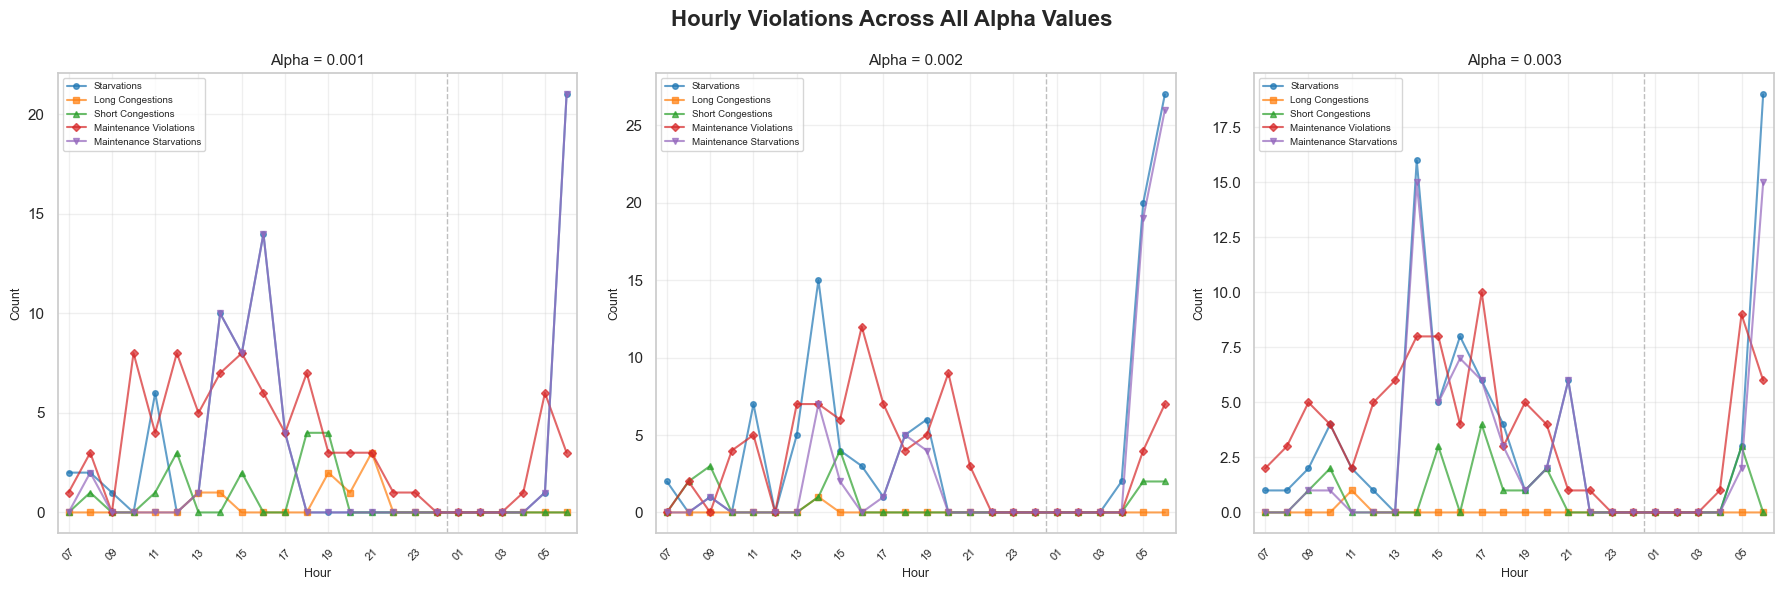

In [45]:
# Optional: Create a summary plot showing all alphas in subplots
n_alphas = len(unique_alphas)
n_cols = 3
n_rows = (n_alphas + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.suptitle('Hourly Violations Across All Alpha Values', fontsize=16, fontweight='bold')

# Flatten axes array if needed
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
markers = ['o', 's', '^', 'D', 'v']

for idx, alpha in enumerate(unique_alphas):
    ax = axes[idx]
    
    # Filter data for this alpha
    alpha_data = combined_df[combined_df['alpha'] == alpha].copy()
    
    # Create hour sequence for plotting: 7, 8, ..., 24, 1, 2, ..., 6
    hour_sequence = list(range(7, 25)) + list(range(1, 7))
    hour_mapping = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    
    # Create a sorted dataframe with hours in display order
    alpha_data_sorted = alpha_data.copy()
    alpha_data_sorted['Plot_Order'] = alpha_data_sorted['Hour'].map(hour_mapping)
    alpha_data_sorted = alpha_data_sorted.sort_values('Plot_Order')
    
    # Plot each violation type
    for i, violation_type in enumerate(violation_types):
        if violation_type in alpha_data_sorted.columns:
            ax.plot(
                alpha_data_sorted['Plot_Order'],
                alpha_data_sorted[violation_type],
                marker=markers[i % len(markers)],
                color=colors[i % len(colors)],
                label=violation_type,
                linewidth=1.5,
                markersize=4,
                alpha=0.7
            )
    
    ax.set_title(f'Alpha = {alpha:.3f}', fontsize=11)
    ax.set_xlabel('Hour', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to show hours 7-24, then 1-6
    hour_labels = [f"{h:02d}" for h in hour_sequence]
    # Map hours to plot positions: 7->7, 8->8, ..., 24->24, 1->25, 2->26, ..., 6->30
    hour_to_position = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    positions = [hour_to_position[h] for h in hour_sequence]
    
    ax.set_xlim(left=6.5, right=30.5)
    ax.set_xticks(positions[::2])  # Show every other hour to avoid crowding
    ax.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), 2)], rotation=45, fontsize=8)
    ax.axvline(x=24.5, color='gray', linestyle='--', alpha=0.5, linewidth=1)

# Hide unused subplots
for idx in range(len(unique_alphas), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save the combined plot
output_dir = results_dir_root / 'hourly_violation_plots'
output_dir.mkdir(exist_ok=True)
output_file = output_dir / 'all_alphas_hourly_violations.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Saved combined plot: {output_file}")

plt.show()


# Vehicle Operations Analysis

Plot bike pickups, deliveries, and maintenance time per hour across different alpha values.


In [46]:
# Vehicle operations data should already be loaded in combined_df
# Check available columns
print("Available columns:")
print(list(combined_df.columns))
print("\nSample data:")
print(combined_df[['Hour', 'alpha', 'Bike Pickups', 'Bike Deliveries', 'Maintenance Time (minutes)']].head(10))


Available columns:
['Starvations', 'Long Congestions', 'Short Congestions', 'Maintenance Violations', 'Maintenance Starvations', 'Seed', 'Time (minutes)', 'Bike Pickups', 'Bike Deliveries', 'Maintenance Time (minutes)', 'alpha', 'Hour']

Sample data:
   Hour  alpha  Bike Pickups  Bike Deliveries  Maintenance Time (minutes)
0     7  0.001            33               23                        0.00
1     8  0.001            17               19                        0.00
2     9  0.001            25               13                        0.48
3    10  0.001            23               23                        0.21
4    11  0.001            17               27                        0.00
5    12  0.001            28               25                        0.00
6    13  0.001            20               21                        0.00
7    14  0.001            24               26                        0.75
8    15  0.001            21               19                        0.32
9    16  

Plotting 3 operation types: ['Bike Pickups', 'Bike Deliveries', 'Maintenance Time (minutes)']

Creating vehicle operations plots for 3 alpha values
Saved: ..\..\simulation_results\vehicle_operations_plots\vehicle_operations_alpha_0.001.png


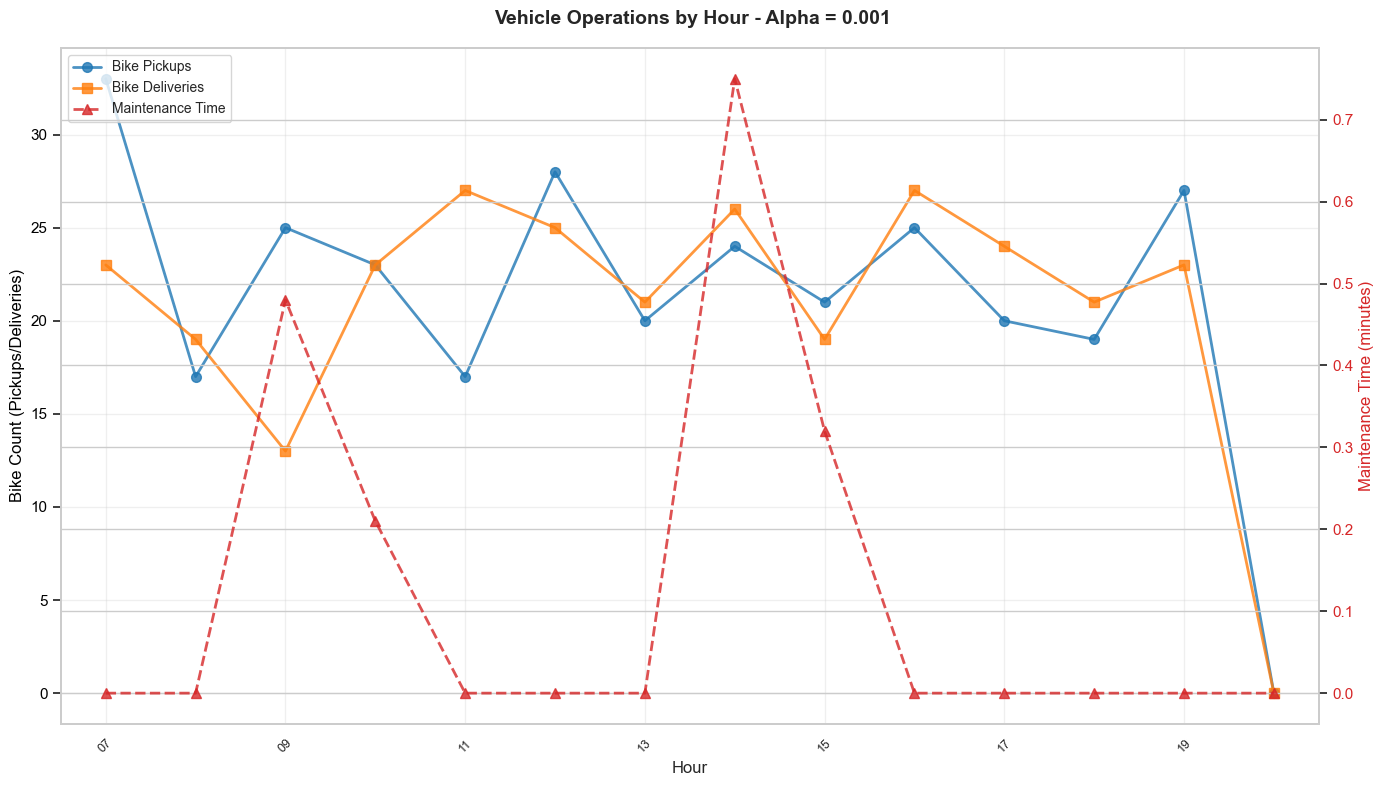

Saved: ..\..\simulation_results\vehicle_operations_plots\vehicle_operations_alpha_0.002.png


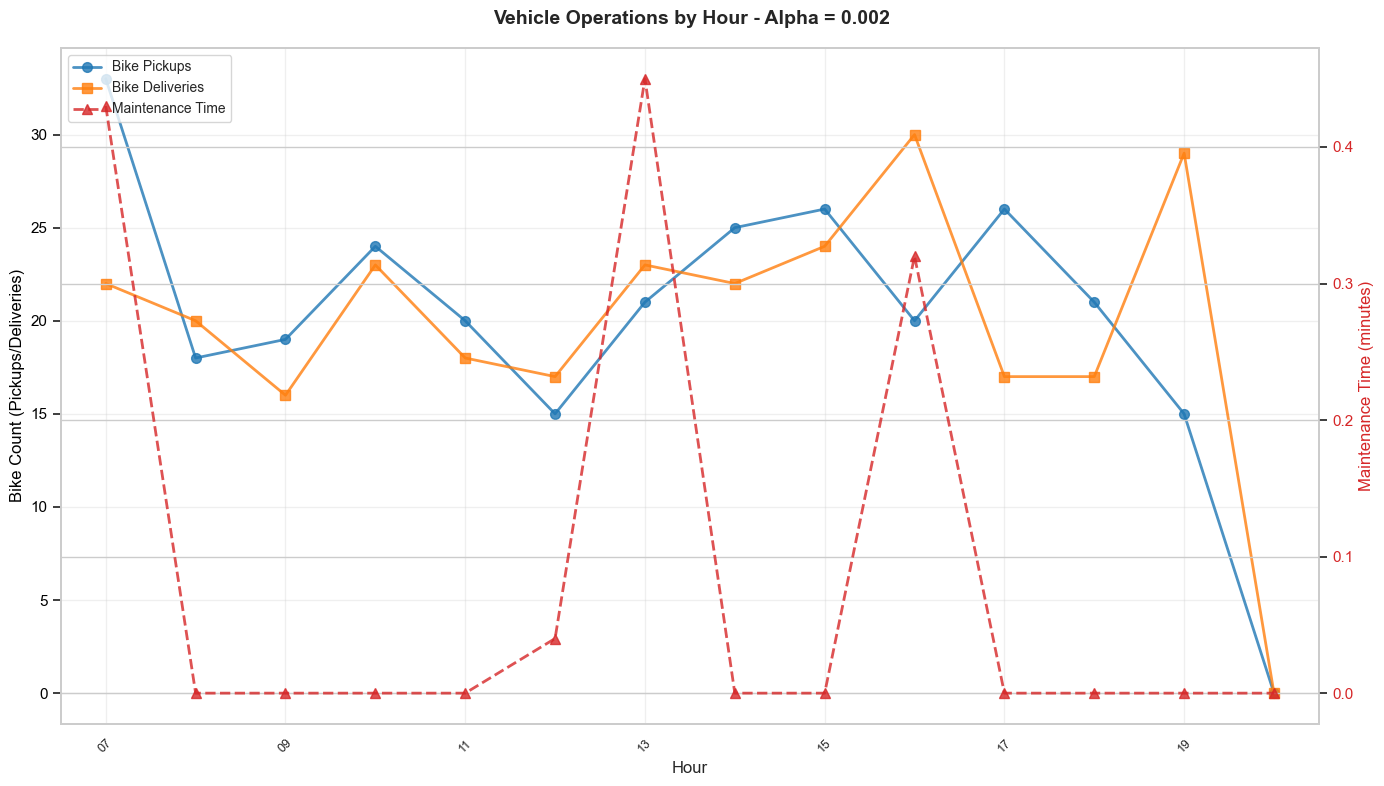

Saved: ..\..\simulation_results\vehicle_operations_plots\vehicle_operations_alpha_0.003.png


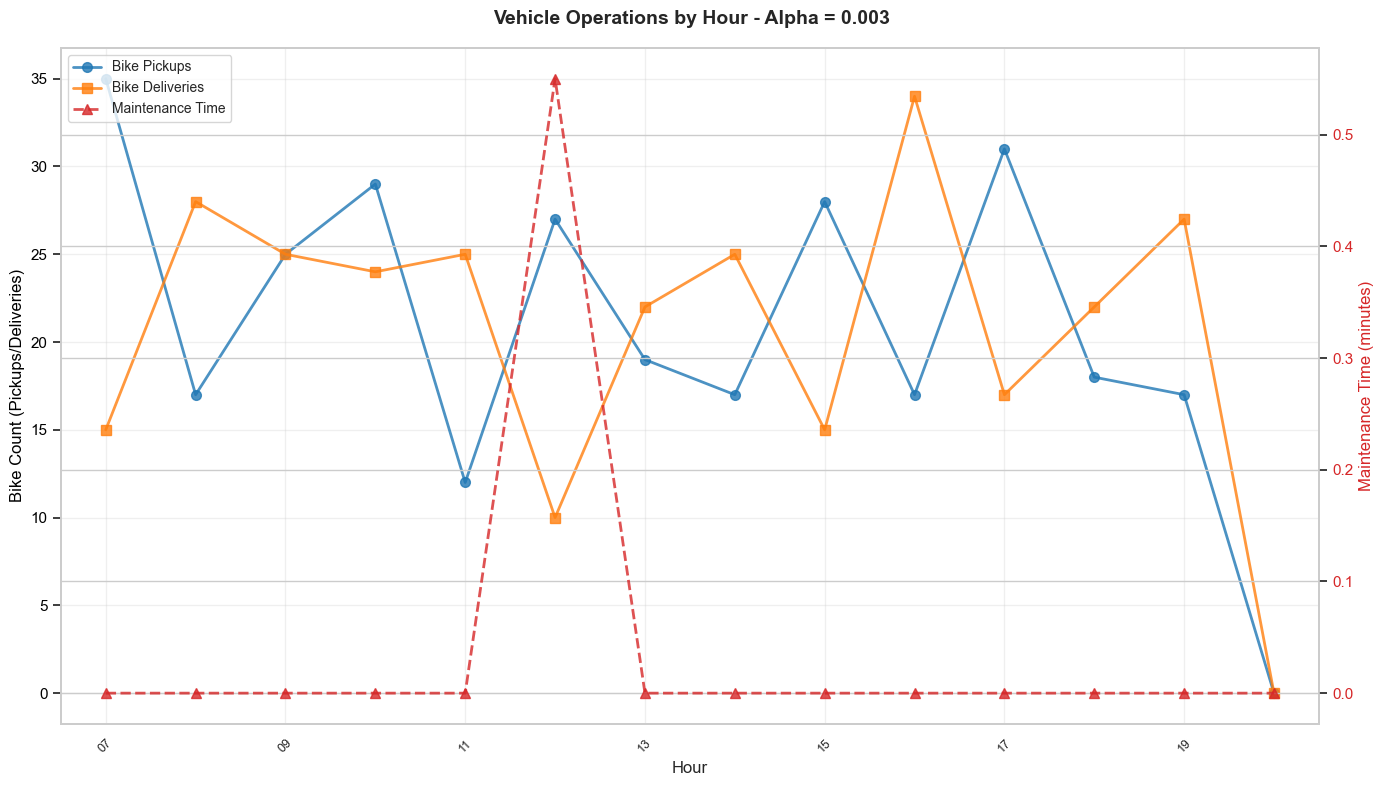


All vehicle operations plots created successfully!


In [47]:
# Create plots for vehicle operations (one plot per alpha)
vehicle_operations = [
    'Bike Pickups',
    'Bike Deliveries',
    'Maintenance Time (minutes)'
]

# Verify all columns exist
available_ops = [op for op in vehicle_operations if op in combined_df.columns]
if len(available_ops) < len(vehicle_operations):
    missing = set(vehicle_operations) - set(available_ops)
    print(f"Warning: Missing columns: {missing}")
    vehicle_operations = available_ops

print(f"Plotting {len(vehicle_operations)} operation types: {vehicle_operations}")

# Get unique alpha values
unique_alphas = sorted(combined_df['alpha'].unique())
print(f"\nCreating vehicle operations plots for {len(unique_alphas)} alpha values")

# Create one plot per alpha value
for alpha in unique_alphas:
    # Filter data for this alpha and only service window hours (7-20)
    alpha_data = combined_df[(combined_df['alpha'] == alpha) & 
                             (combined_df['Hour'] >= 7) & 
                             (combined_df['Hour'] <= 20)].copy()
    
    # Create hour sequence for plotting: 7, 8, ..., 20 (service window only)
    hour_sequence = list(range(7, 21))
    hour_mapping = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    
    # Create a sorted dataframe with hours in display order
    alpha_data_sorted = alpha_data.copy()
    alpha_data_sorted['Plot_Order'] = alpha_data_sorted['Hour'].map(hour_mapping)
    alpha_data_sorted = alpha_data_sorted.sort_values('Plot_Order')
    
    # Create figure with dual y-axes (counts on left, maintenance time on right)
    fig, ax1 = plt.subplots(figsize=(14, 8))
    
    # Plot pickups and deliveries on primary y-axis (left)
    colors_ops = ['tab:blue', 'tab:orange', 'tab:green']
    markers_ops = ['o', 's', '^']
    
    # Primary y-axis: Bike counts
    ax1.set_xlabel('Hour', fontsize=12)
    ax1.set_ylabel('Bike Count (Pickups/Deliveries)', fontsize=12, color='black')
    
    for i, op in enumerate(['Bike Pickups', 'Bike Deliveries']):
        if op in alpha_data_sorted.columns:
            ax1.plot(
                alpha_data_sorted['Plot_Order'],
                alpha_data_sorted[op],
                marker=markers_ops[i],
                color=colors_ops[i],
                label=op,
                linewidth=2,
                markersize=7,
                alpha=0.8
            )
    
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.grid(True, alpha=0.3)
    
    # Secondary y-axis: Maintenance time
    ax2 = ax1.twinx()
    ax2.set_ylabel('Maintenance Time (minutes)', fontsize=12, color='tab:red')
    
    if 'Maintenance Time (minutes)' in alpha_data_sorted.columns:
        ax2.plot(
            alpha_data_sorted['Plot_Order'],
            alpha_data_sorted['Maintenance Time (minutes)'],
            marker='^',
            color='tab:red',
            label='Maintenance Time',
            linewidth=2,
            markersize=7,
            alpha=0.8,
            linestyle='--'
        )
    
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    # Set title
    fig.suptitle(f'Vehicle Operations by Hour - Alpha = {alpha:.3f}', 
                 fontsize=14, fontweight='bold')
    
    # Set x-axis to show hours 7-20 (service window: 07:00 to 20:00)
    if len(alpha_data_sorted) > 0:
        hour_labels = [f"{h:02d}" for h in hour_sequence]
        hour_to_position = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
        positions = [hour_to_position[h] for h in hour_sequence]
        
        ax1.set_xlim(left=6.5, right=20.5)
        ax1.set_xticks(positions[::2])  # Show every other hour to avoid crowding
        ax1.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), 2)], 
                           rotation=45, fontsize=9)
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    
    # Save the plot
    output_dir = results_dir_root / 'vehicle_operations_plots'
    output_dir.mkdir(exist_ok=True)
    output_file = output_dir / f'vehicle_operations_alpha_{alpha:.3f}.png'
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f"Saved: {output_file}")
    
    plt.show()
    plt.close()

print("\nAll vehicle operations plots created successfully!")


Saved combined plot: ..\..\simulation_results\vehicle_operations_plots\all_alphas_vehicle_operations.png


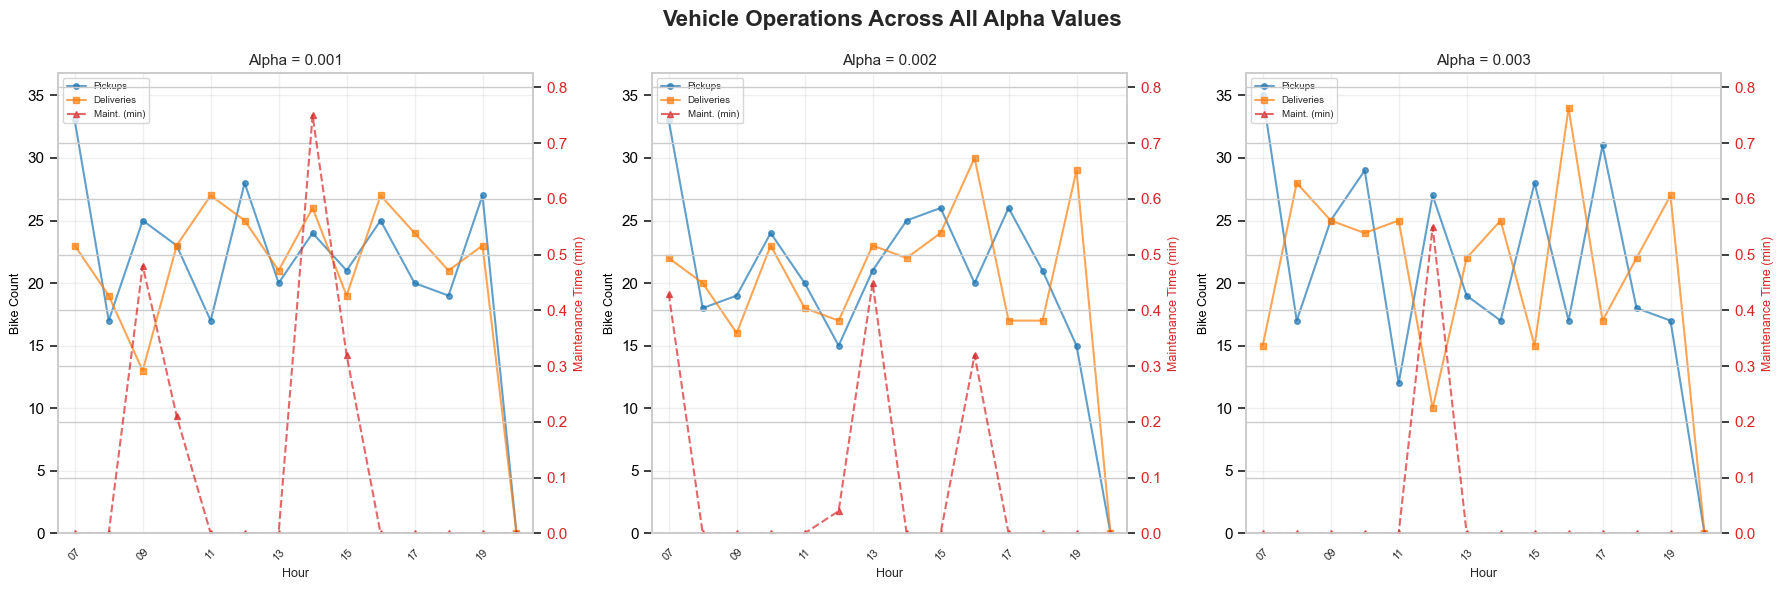

In [48]:
# Create a combined plot showing all alphas in subplots
n_alphas = len(unique_alphas)
n_cols = 3
n_rows = (n_alphas + n_cols - 1) // n_cols

# First, calculate global min/max for equal y-axis scaling
# Filter to service window hours (7-20) for all alphas
service_window_data = combined_df[(combined_df['Hour'] >= 7) & 
                                  (combined_df['Hour'] <= 20)].copy()

# Find min/max for bike operations (left y-axis)
bike_ops_min = min(
    service_window_data['Bike Pickups'].min() if 'Bike Pickups' in service_window_data.columns else 0,
    service_window_data['Bike Deliveries'].min() if 'Bike Deliveries' in service_window_data.columns else 0
)
bike_ops_max = max(
    service_window_data['Bike Pickups'].max() if 'Bike Pickups' in service_window_data.columns else 0,
    service_window_data['Bike Deliveries'].max() if 'Bike Deliveries' in service_window_data.columns else 0
)

# Add some padding (5% on each side)
bike_ops_range = bike_ops_max - bike_ops_min
if bike_ops_range > 0:
    bike_ops_min = max(0, bike_ops_min - bike_ops_range * 0.05)
    bike_ops_max = bike_ops_max + bike_ops_range * 0.05
else:
    bike_ops_min = 0
    bike_ops_max = 10

# Find min/max for maintenance time (right y-axis)
if 'Maintenance Time (minutes)' in service_window_data.columns:
    maint_min = service_window_data['Maintenance Time (minutes)'].min()
    maint_max = service_window_data['Maintenance Time (minutes)'].max()
    maint_range = maint_max - maint_min
    
    # Make granular enough so it lifts off the bottom
    if maint_range > 0:
        # Add padding and ensure minimum is below the actual min
        maint_min = max(0, maint_min - maint_range * 0.1)
        maint_max = maint_max + maint_range * 0.1
    else:
        # If all values are the same or zero, set a small range
        if maint_max == 0:
            maint_min = 0
            maint_max = 1
        else:
            maint_min = max(0, maint_max * 0.9)
            maint_max = maint_max * 1.1
else:
    maint_min = 0
    maint_max = 10

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
fig.suptitle('Vehicle Operations Across All Alpha Values', fontsize=16, fontweight='bold')

# Flatten axes array if needed
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes = axes.flatten()

for idx, alpha in enumerate(unique_alphas):
    ax1 = axes[idx]
    
    # Filter data for this alpha and only service window hours (7-20)
    alpha_data = combined_df[(combined_df['alpha'] == alpha) & 
                             (combined_df['Hour'] >= 7) & 
                             (combined_df['Hour'] <= 20)].copy()
    
    # Create hour sequence for plotting: 7, 8, ..., 20 (service window only)
    hour_sequence = list(range(7, 21))
    hour_mapping = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    
    alpha_data_sorted = alpha_data.copy()
    alpha_data_sorted['Plot_Order'] = alpha_data_sorted['Hour'].map(hour_mapping)
    alpha_data_sorted = alpha_data_sorted.sort_values('Plot_Order')
    
    # Plot bike operations on left y-axis
    colors = ['tab:blue', 'tab:orange']
    markers = ['o', 's']
    labels = ['Pickups', 'Deliveries']
    
    for i, (op, label) in enumerate(zip(['Bike Pickups', 'Bike Deliveries'], labels)):
        if op in alpha_data_sorted.columns:
            ax1.plot(
                alpha_data_sorted['Plot_Order'],
                alpha_data_sorted[op],
                marker=markers[i],
                color=colors[i],
                label=label,
                linewidth=1.5,
                markersize=4,
                alpha=0.7
            )
    
    # Set equal y-axis limits for bike operations across all subplots
    ax1.set_ylim(bike_ops_min, bike_ops_max)
    ax1.set_ylabel('Bike Count', fontsize=9, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    
    # Create right y-axis for maintenance time
    ax2 = ax1.twinx()
    
    if 'Maintenance Time (minutes)' in alpha_data_sorted.columns:
        ax2.plot(
            alpha_data_sorted['Plot_Order'],
            alpha_data_sorted['Maintenance Time (minutes)'],
            marker='^',
            color='tab:red',
            label='Maint. (min)',
            linewidth=1.5,
            markersize=4,
            alpha=0.7,
            linestyle='--'
        )
    
    # Set y-axis limits for maintenance time
    ax2.set_ylim(maint_min, maint_max)
    ax2.set_ylabel('Maintenance Time (min)', fontsize=9, color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    
    ax1.set_title(f'Alpha = {alpha:.3f}', fontsize=11)
    ax1.set_xlabel('Hour', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=7)
    
    # Set x-axis to show hours 7-20 (service window: 07:00 to 20:00)
    hour_labels = [f"{h:02d}" for h in hour_sequence]
    hour_to_position = {h: idx + 7 for idx, h in enumerate(hour_sequence)}
    positions = [hour_to_position[h] for h in hour_sequence]
    
    ax1.set_xlim(left=6.5, right=20.5)
    ax1.set_xticks(positions[::2])  # Show every other hour to avoid crowding
    ax1.set_xticklabels([hour_labels[i] for i in range(0, len(hour_labels), 2)], 
                       rotation=45, fontsize=8)

# Hide unused subplots
for idx in range(len(unique_alphas), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()

# Save the combined plot
output_dir = results_dir_root / 'vehicle_operations_plots'
output_dir.mkdir(exist_ok=True)
output_file = output_dir / 'all_alphas_vehicle_operations.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f"Saved combined plot: {output_file}")

plt.show()


## hourly curves for all alpha

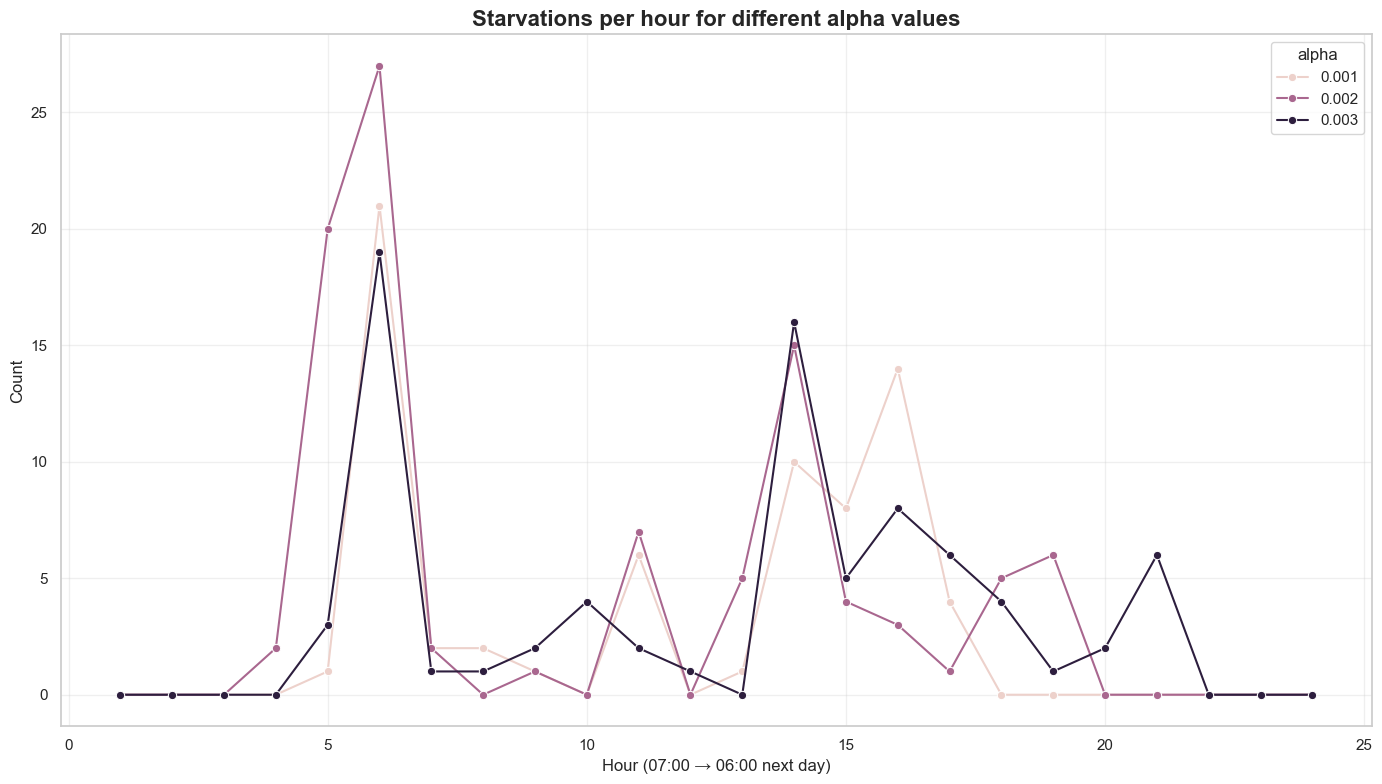

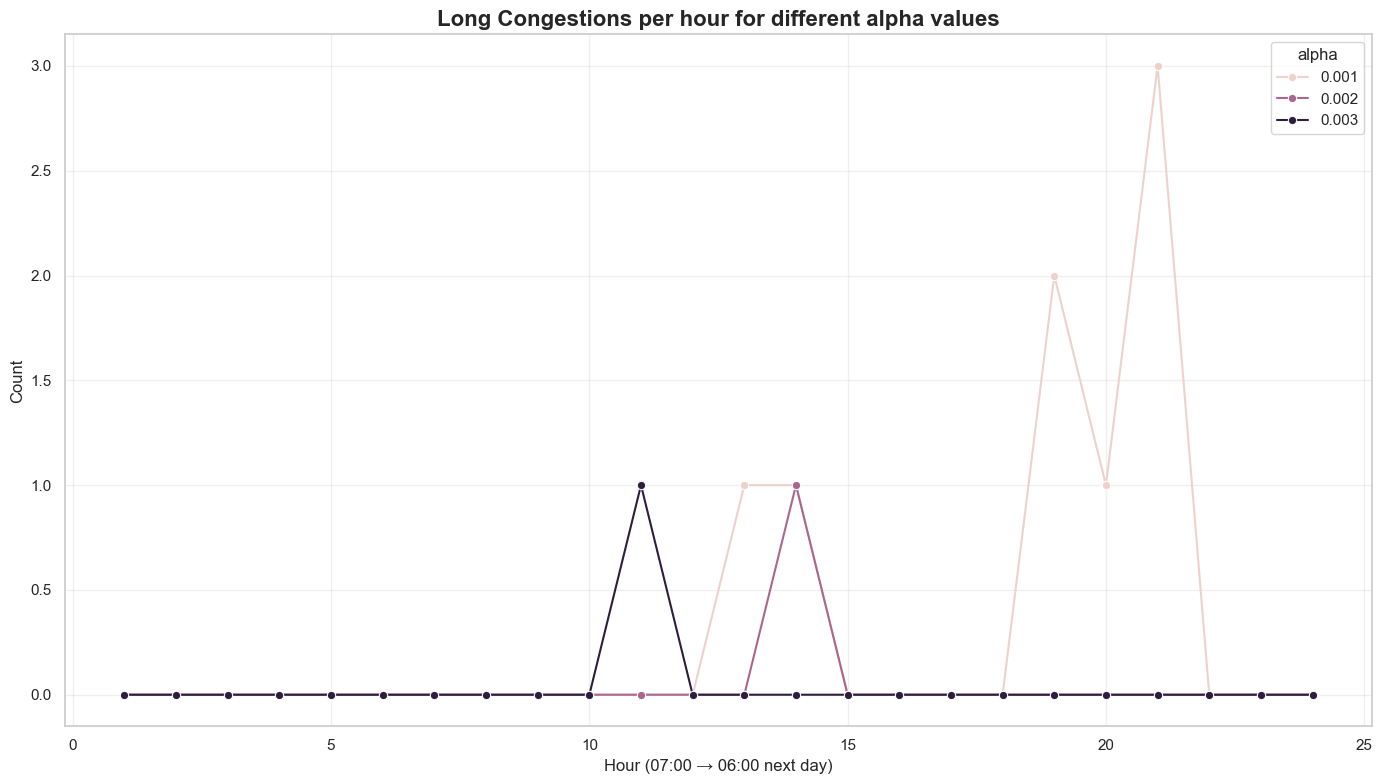

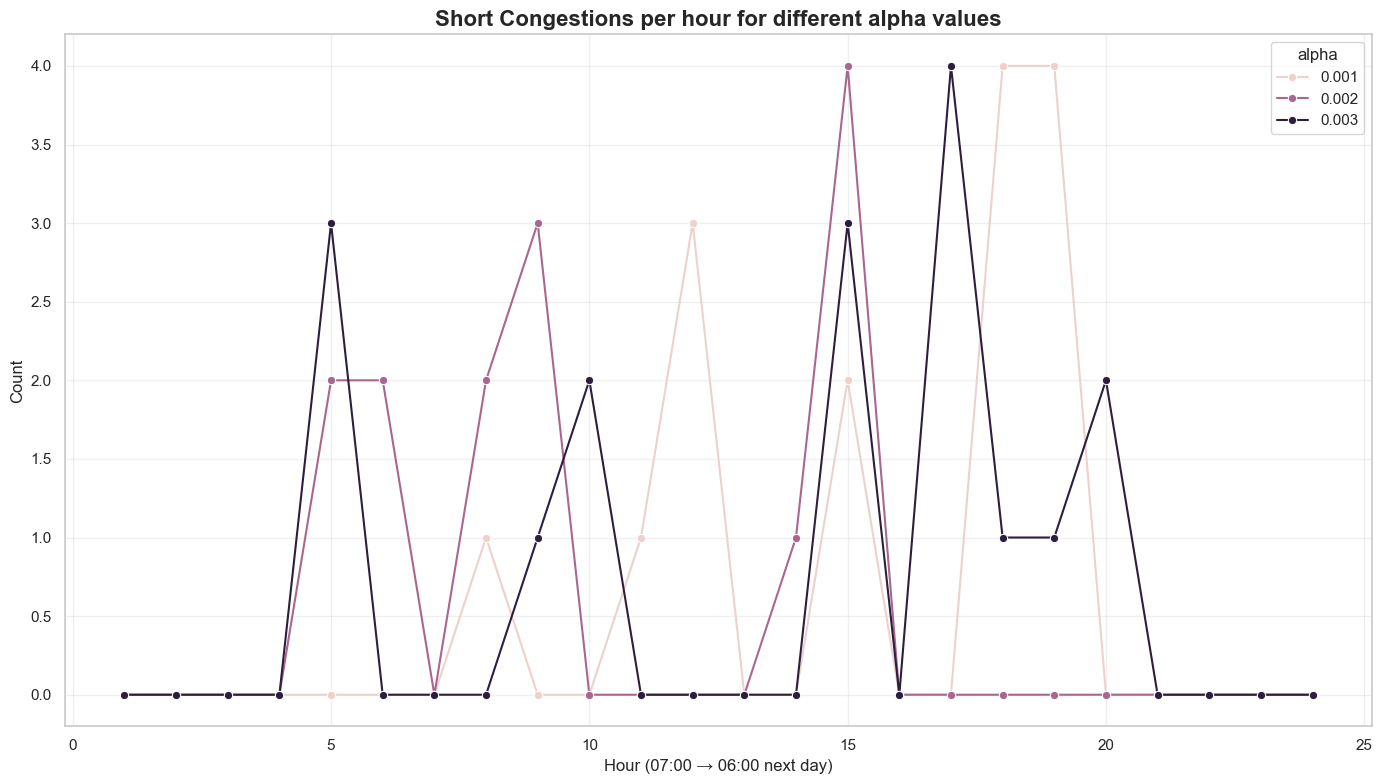

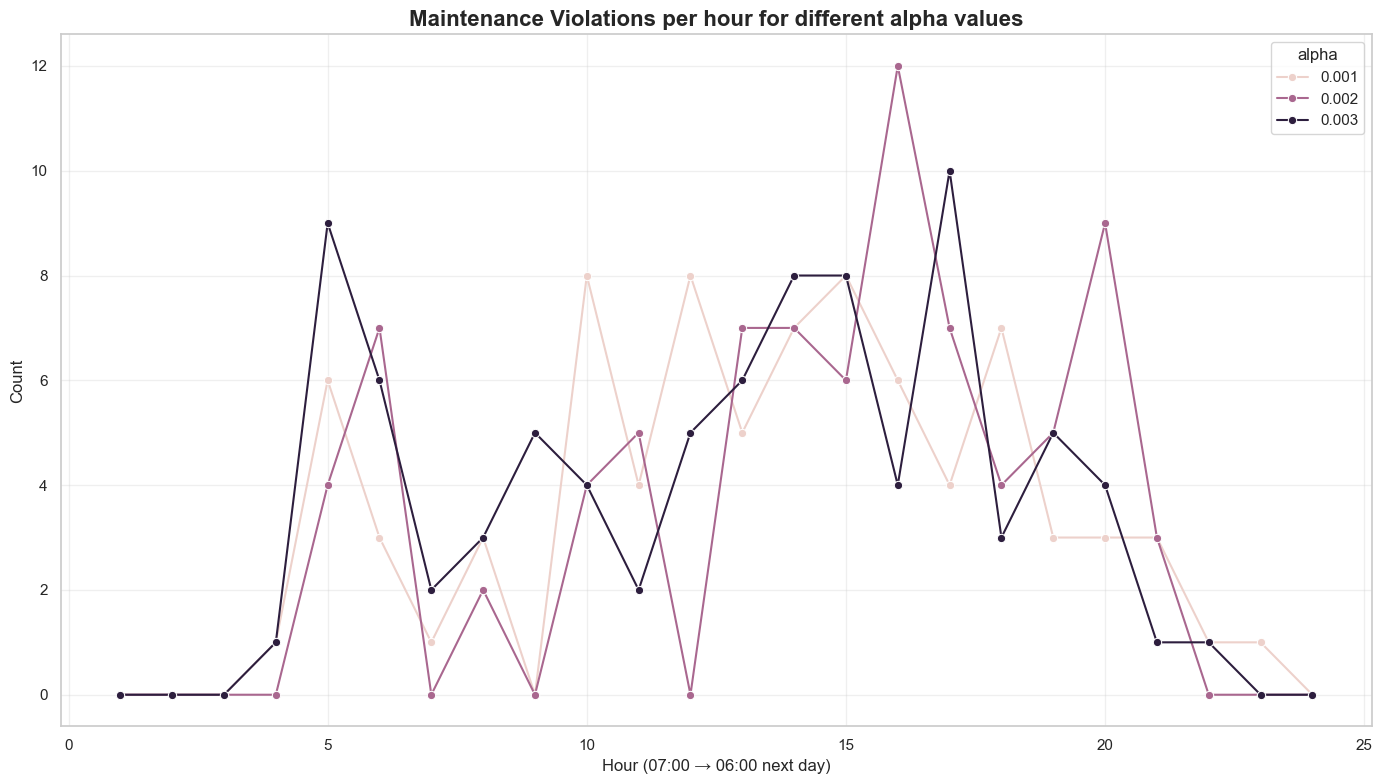

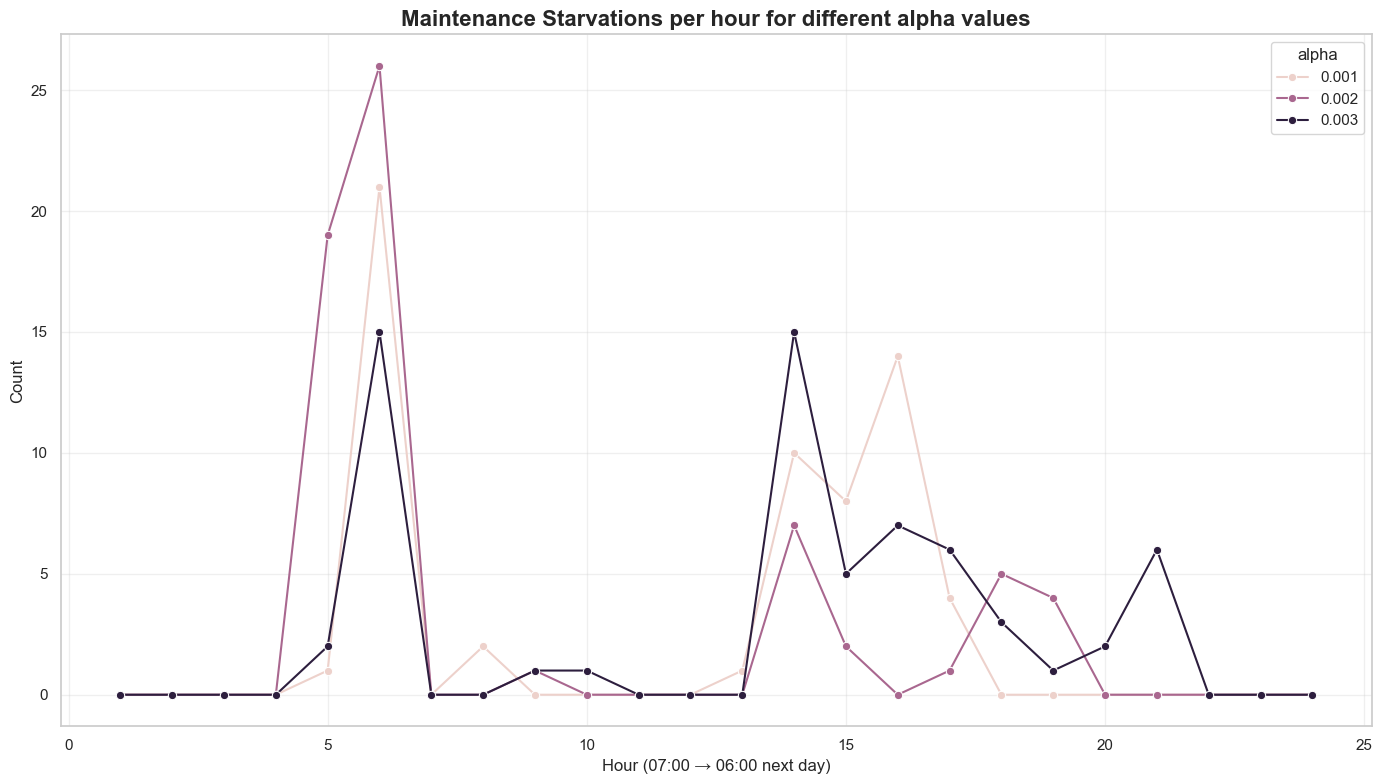

In [49]:
# Ensure hours are in the correct circular order: 7–24, then 1–6
hour_order = list(range(7, 25)) + list(range(1, 7))

combined_df["Hour_cat"] = pd.Categorical(
    combined_df["Hour"], categories=hour_order, ordered=True
)

for v in violation_types:
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=combined_df,
        x="Hour_cat",
        y=v,
        hue="alpha",
        marker="o"
    )
    plt.title(f"{v} per hour for different alpha values", fontsize=16, fontweight="bold")
    plt.xlabel("Hour (07:00 → 06:00 next day)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.legend(title="alpha")
    plt.tight_layout()
    plt.show()


# Daily totals per alpha

In [50]:
# Aggregate daily totals per alpha
daily_totals = combined_df.groupby("alpha")[violation_types].sum().reset_index()
daily_totals = daily_totals.sort_values("alpha")

display(daily_totals)


,alpha,Starvations,Long Congestions,Short Congestions,Maintenance Violations,Maintenance Starvations
0,0.001,70,8,15,82,61
1,0.002,98,1,14,82,65
2,0.003,81,1,17,87,64


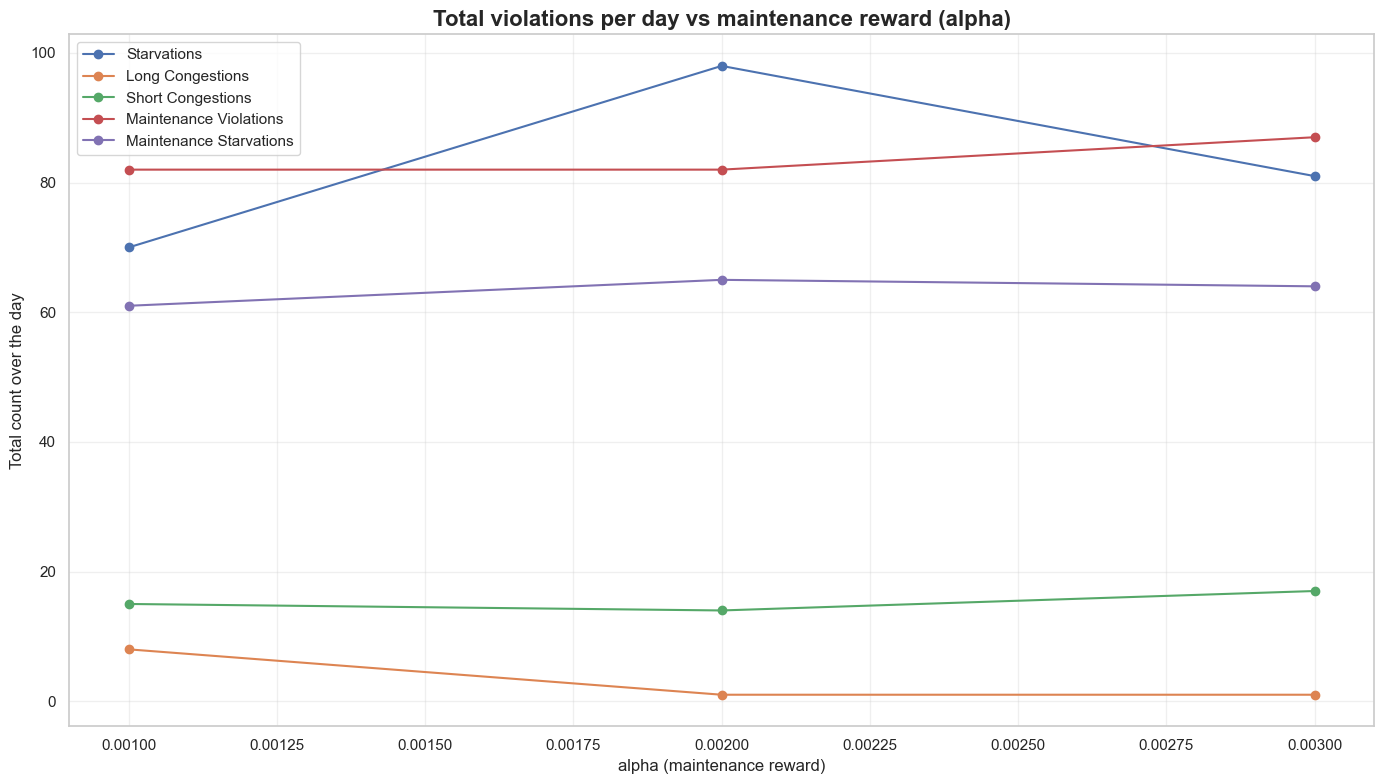

In [51]:
plt.figure(figsize=(14, 8))

for v in violation_types:
    plt.plot(
        daily_totals["alpha"],
        daily_totals[v],
        marker="o",
        label=v
    )

plt.title("Total violations per day vs maintenance reward (alpha)", fontsize=16, fontweight="bold")
plt.xlabel("alpha (maintenance reward)")
plt.ylabel("Total count over the day")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


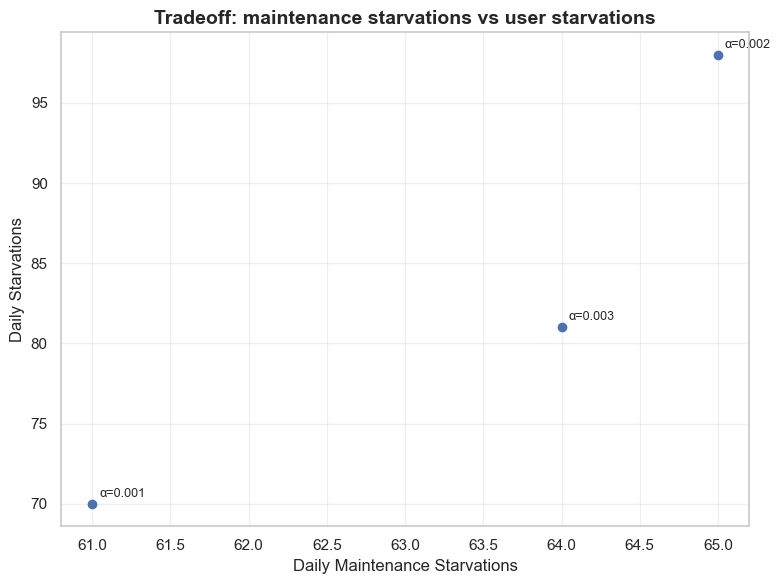

In [52]:
# Make sure these columns exist
cols_needed = ["Maintenance Starvations", "Maintenance Violations", "Starvations", "Long Congestions"]
for c in cols_needed:
    if c not in daily_totals.columns:
        print(f"Missing {c} in daily_totals")

plt.figure(figsize=(8, 6))

x = daily_totals["Maintenance Starvations"]
y = daily_totals["Starvations"]

plt.scatter(x, y)

for _, row in daily_totals.iterrows():
    plt.annotate(
        f"α={row['alpha']}",
        (row["Maintenance Starvations"], row["Starvations"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

plt.xlabel("Daily Maintenance Starvations")
plt.ylabel("Daily Starvations")
plt.title("Tradeoff: maintenance starvations vs user starvations", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


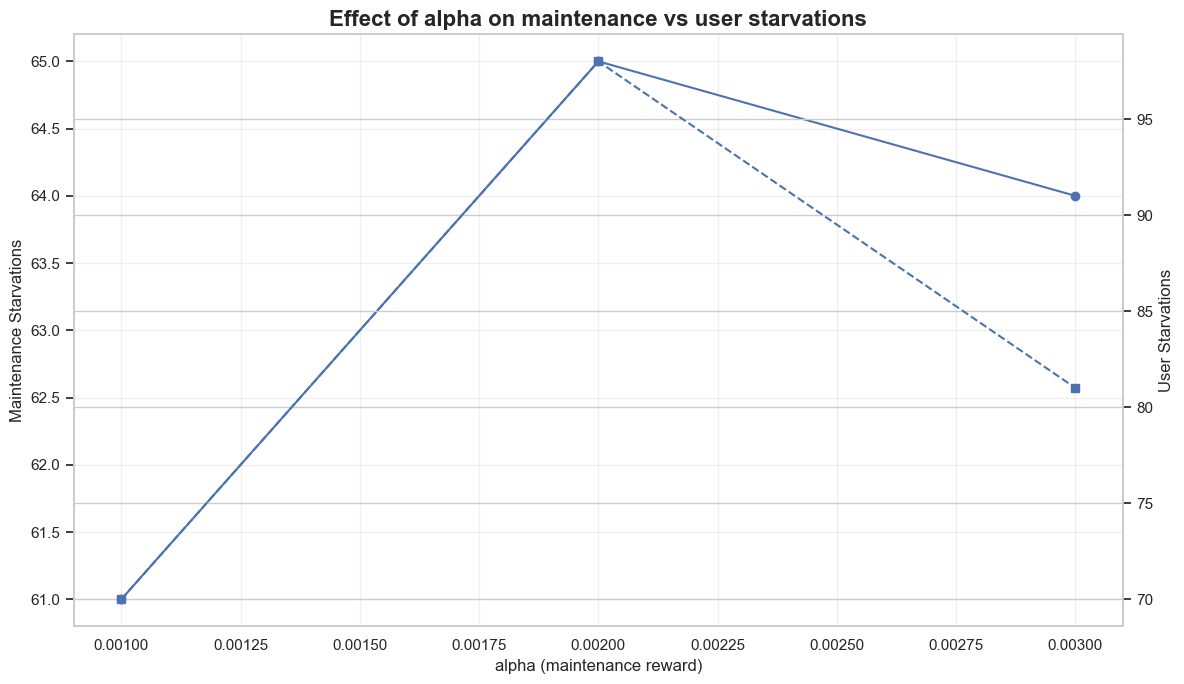

In [53]:
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(
    daily_totals["alpha"],
    daily_totals["Maintenance Starvations"],
    marker="o",
    label="Maintenance Starvations"
)
ax1.set_xlabel("alpha (maintenance reward)")
ax1.set_ylabel("Maintenance Starvations")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    daily_totals["alpha"],
    daily_totals["Starvations"],
    marker="s",
    linestyle="--",
    label="User Starvations",
)
ax2.set_ylabel("User Starvations")

plt.title("Effect of alpha on maintenance vs user starvations", fontsize=16, fontweight="bold")
fig.tight_layout()
plt.show()


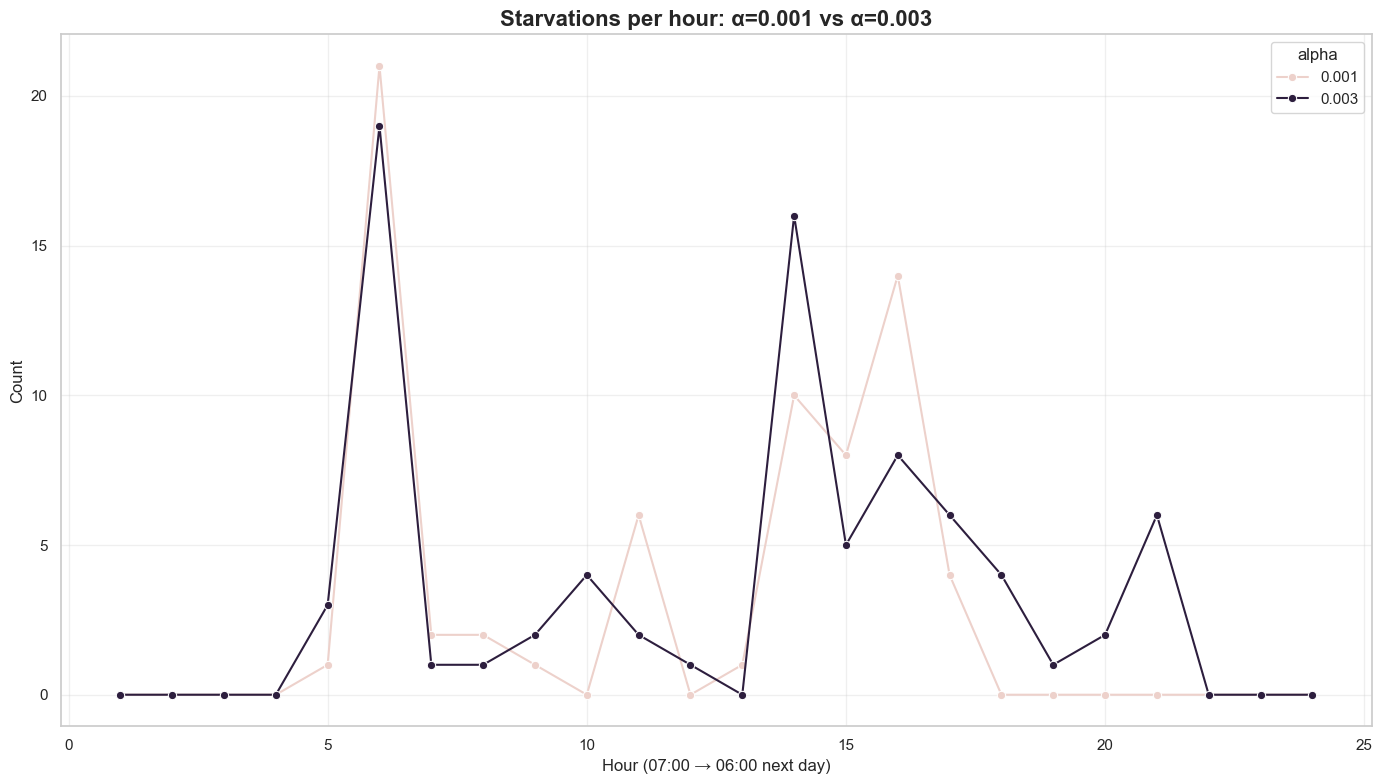

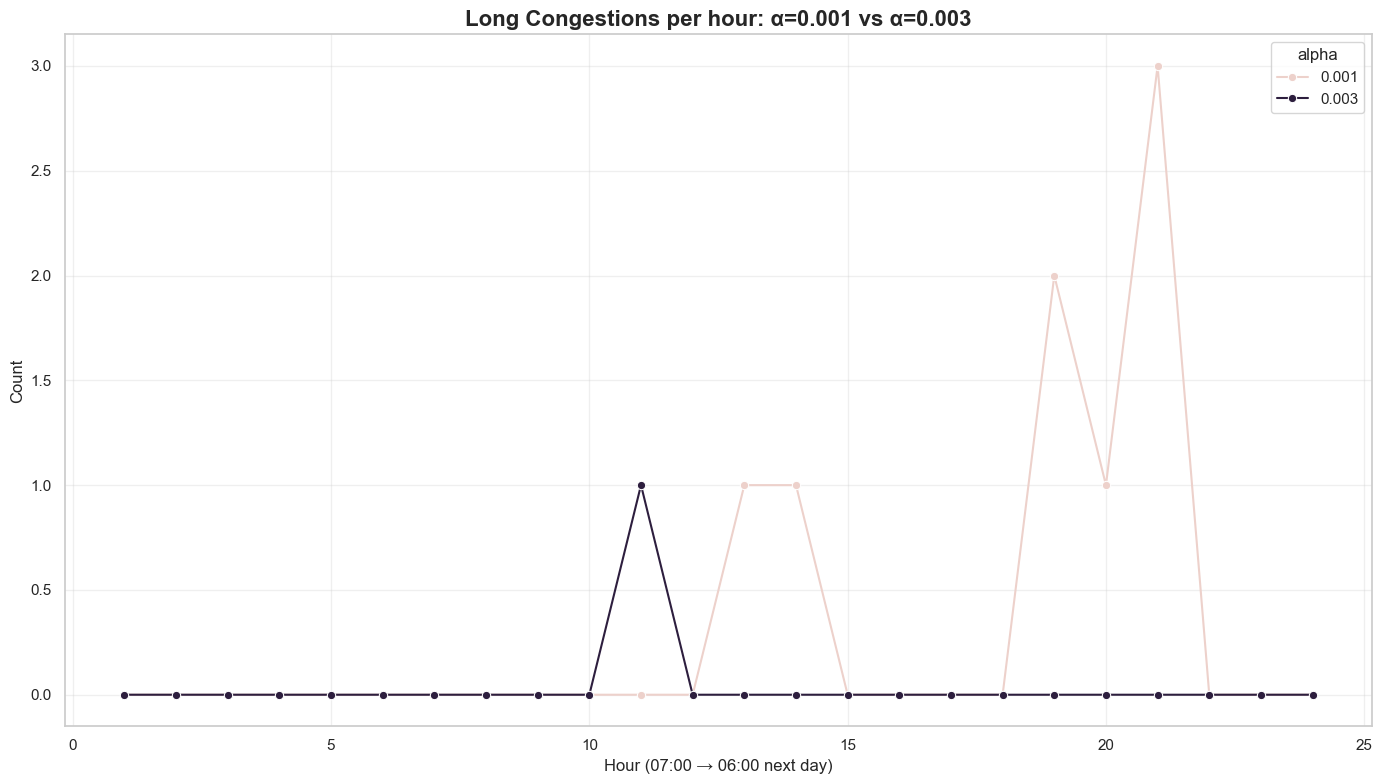

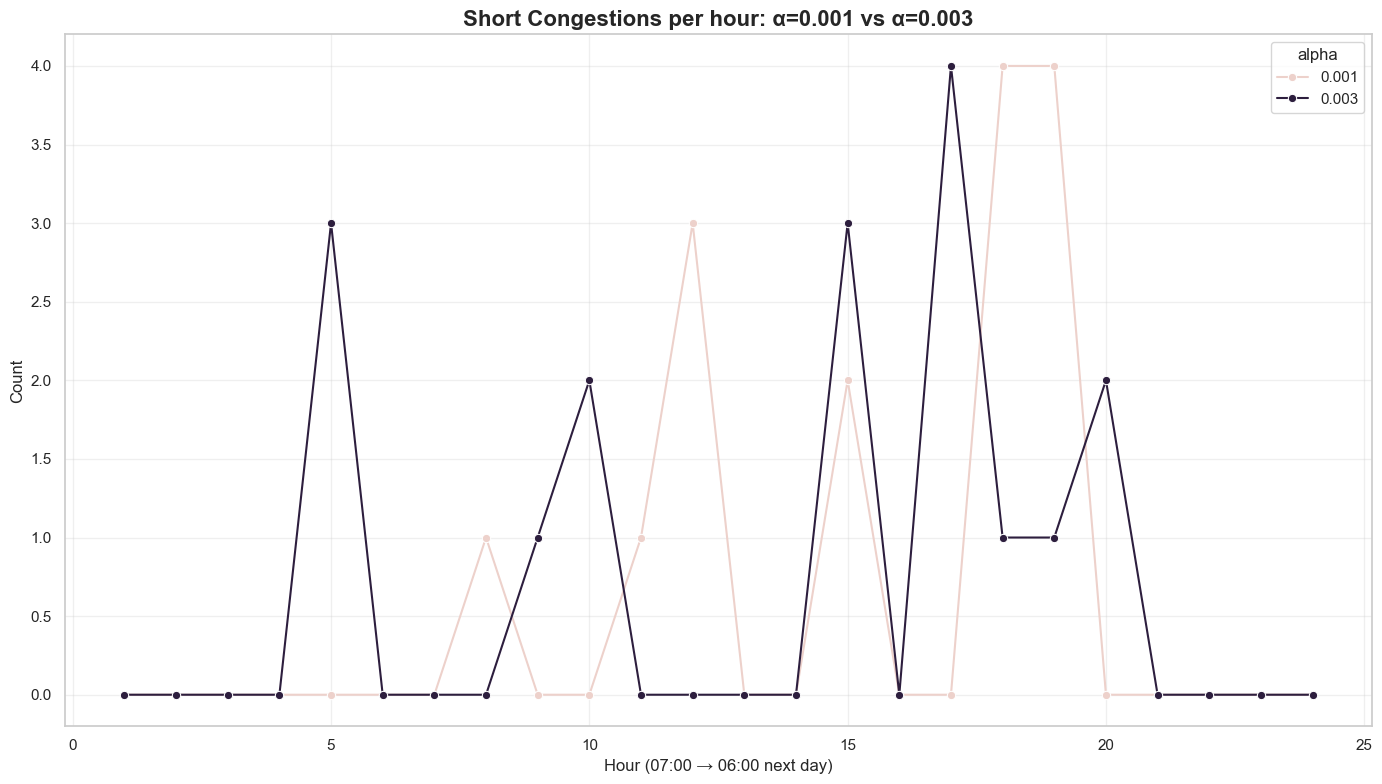

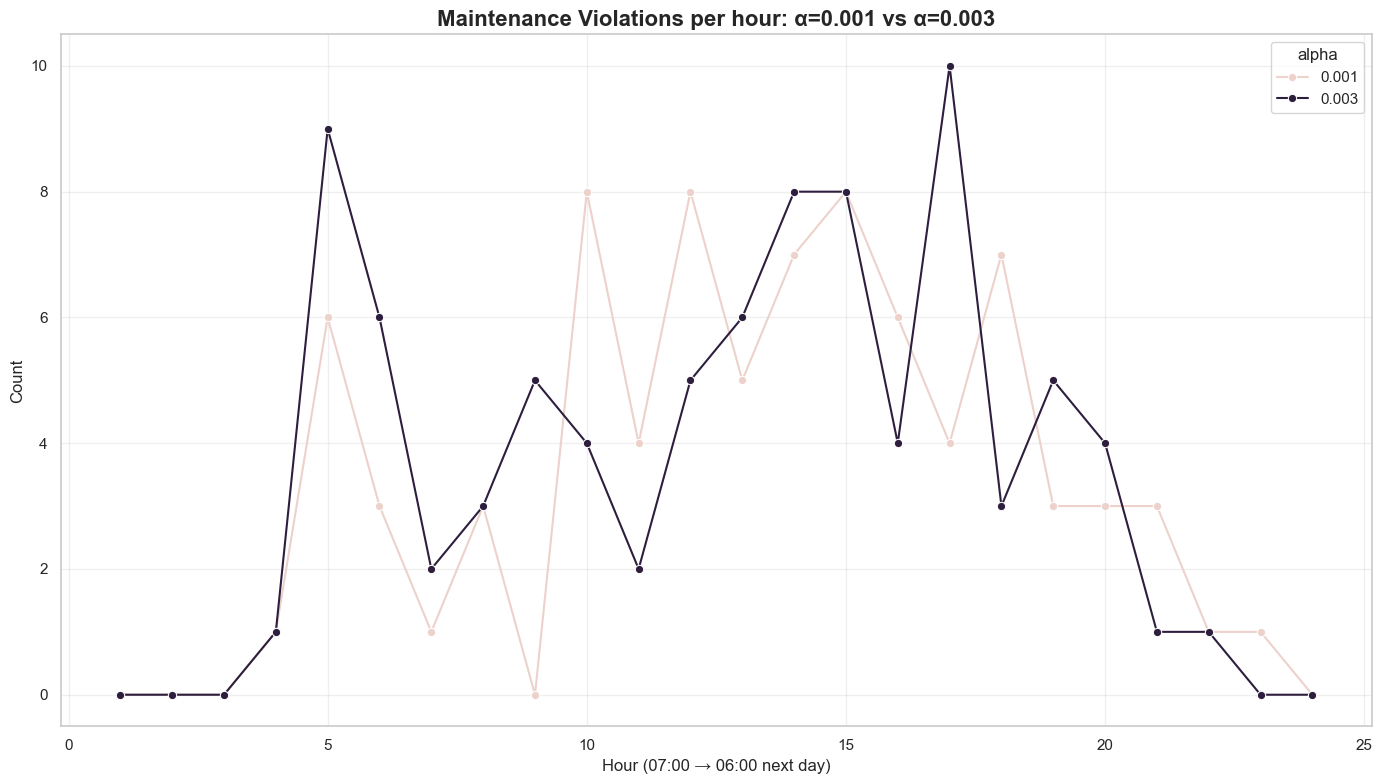

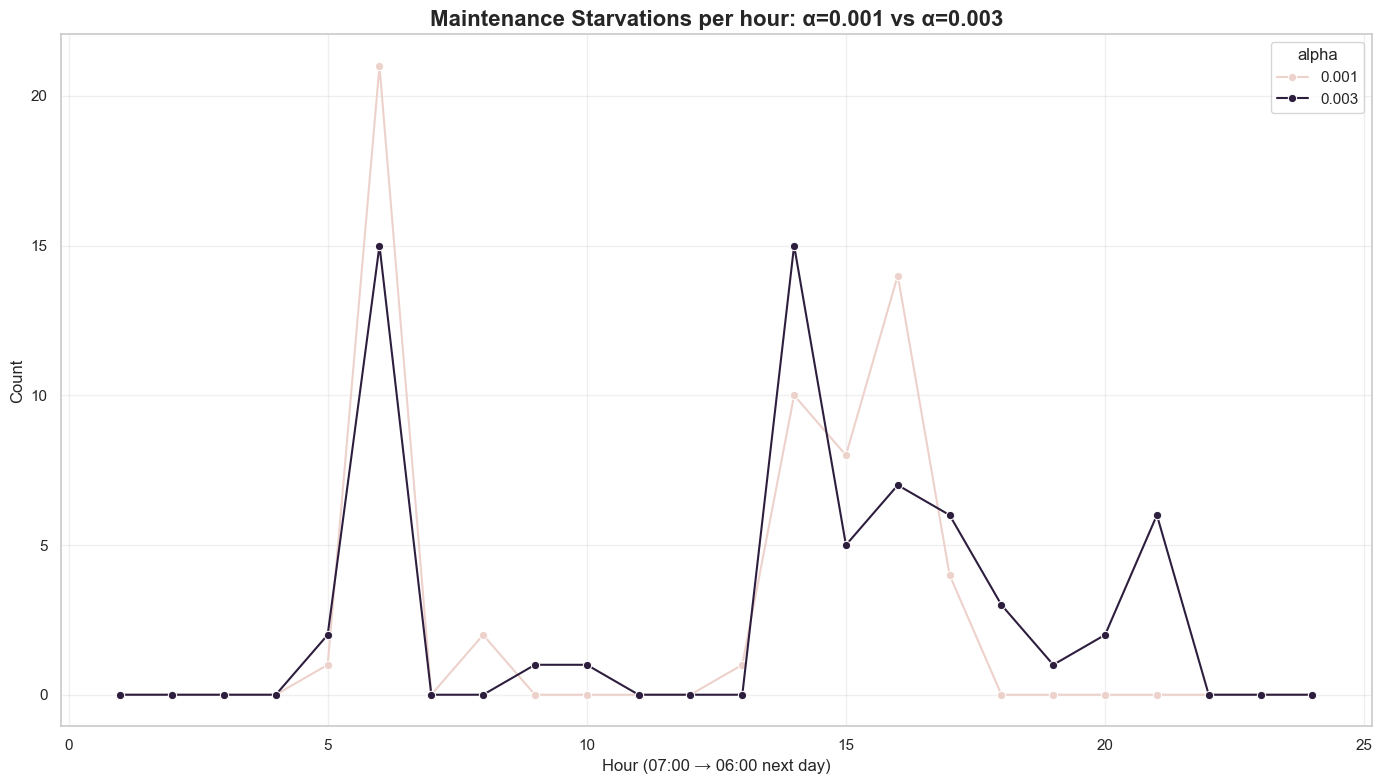

In [54]:
# Pick two alpha values to compare
alpha_low = min(unique_alphas)
alpha_high = max(unique_alphas)

subset = combined_df[combined_df["alpha"].isin([alpha_low, alpha_high])].copy()
subset["Hour_cat"] = pd.Categorical(
    subset["Hour"], categories=hour_order, ordered=True
)

for v in violation_types:
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=subset,
        x="Hour_cat",
        y=v,
        hue="alpha",
        marker="o"
    )
    plt.title(f"{v} per hour: α={alpha_low} vs α={alpha_high}", fontsize=16, fontweight="bold")
    plt.xlabel("Hour (07:00 → 06:00 next day)")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Bike criticality analysis

In [55]:
# Configuration
output_file = Path('../../../../output_TD_3011250903.txt')
#results_dir = Path('../../simulation_results/third_test_of_maintenance_rewards')

# Set plot style
sns.set_theme(style="whitegrid")

print(f"Reading output file: {output_file}")
print(f"File exists: {output_file.exists()}")

if not output_file.exists():
    print("\n⚠️ File not found! Try these alternatives:")
    alternatives = [
        Path('output_TD_3011250903.txt'),
        Path('../output_TD_3011250903.txt'),
        Path('../../output_TD_3011250903.txt'),
        Path('../../../output_TD_3011250903.txt'),
        Path('../../../../output_TD_3011250903.txt'),
    ]
    for alt in alternatives:
        if alt.exists():
            print(f"  ✓ Found at: {alt.resolve()}")
            output_file = alt
            break
        else:
            print(f"  ✗ Not at: {alt.resolve()}")


Reading output file: ..\..\..\..\output_TD_3011250903.txt
File exists: True


In [56]:


# Dictionary to store criticality data: {bike_id: [(line_number, criticality), ...]}
bike_criticality = {}

# Pattern to match: "Initialized Bike ID-B0 with maintenance criticality: 0.596"
pattern = re.compile(r'Initialized Bike ID-([A-Z0-9]+) with maintenance criticality: ([\d.]+)')

# Read and parse the file
with open(output_file, 'r') as f:
    for line_num, line in enumerate(f, start=1):
        match = pattern.search(line)
        if match:
            bike_id = match.group(1)
            criticality = float(match.group(2))
            
            if bike_id not in bike_criticality:
                bike_criticality[bike_id] = []
            
            bike_criticality[bike_id].append((line_num, criticality))

print(f"\nFound criticality data for {len(bike_criticality)} bikes")
print(f"\nSample bikes with reset counts:")
for bike_id in sorted(list(bike_criticality.keys()))[:10]:
    print(f"  {bike_id}: {len(bike_criticality[bike_id])} resets")

# Show data for one bike
if 'B0' in bike_criticality:
    print(f"\nExample: Bike B0 criticality values:")
    for line_num, crit in bike_criticality['B0']:
        print(f"  Line {line_num}: {crit:.3f}")


Found criticality data for 0 bikes

Sample bikes with reset counts:
